# Multimodal RAG: Beyond Text RAG
### Classroom session — 30–40 minutes | 100% Free & Local (Ollama, no API keys)

You already know **basic RAG**: PDF → text chunks → embeddings → FAISS → LLM → answer.

Today we extend that pipeline to handle **tables** and **images/diagrams**, not just plain text.

## Traditional RAG (what you already built)
```
Text → Chunks → Embeddings → Vector Search → LLM → Answer
```

## Multimodal RAG (today)
```
Text + Tables + Images
        ↓
Content Extraction (per type)
        ↓
Representation (text chunks / table-as-text / image captions)
        ↓
ONE shared embedding space (unified FAISS index)
        ↓
Retriever (same as before!)
        ↓
Multimodal Context (text + table text + the actual retrieved image)
        ↓
Local Vision-Language Model (VLM)
        ↓
Answer
```

**What changes:** how we *extract* and *represent* each content type before embedding, and what we *send* to the LLM at generation time (an image goes in alongside the text).

**What stays exactly the same:** chunking → embed → FAISS → retrieve. This is the key teaching point — multimodal RAG is not a new algorithm, it's the same retrieval skeleton with richer inputs.

## How today's demo bridges images into a text-based retriever

A 'from scratch' multimodal RAG would use a joint text-image embedding model like CLIP. To keep this classroom-simple and avoid a second embedding model, we use a trick that is common in real systems:

1. Extract each image/table from the PDF.
2. Ask our **local VLM (Qwen2.5-VL via Ollama)** to write a short text description of it (this is called *captioning*).
3. Embed that caption with the **same Sentence-Transformers model** used for normal text — so everything (text chunks, table text, image captions) lives in **one FAISS index**.
4. At answer time, if a retrieved item is an image, we don't just send its caption to the LLM — we send **the original image itself** to the VLM, so it can actually *look* at it and answer precisely.

This keeps the retrieval step identical to plain RAG, while the generation step becomes multimodal.

## 0. Setup — Run this in VS Code (local machine)

**One-time setup, in a terminal (not a notebook cell):**

### Option 1: Standard `venv` + `pip`

```bash
# 1. Create and activate a virtual environment (from the folder that has this notebook)
python3 -m venv .venv
source .venv/bin/activate        # Windows:  .venv\Scripts\activate

# 2. Install dependencies
pip install -r requirements.txt

# 3. Make the venv selectable as a Jupyter kernel
python -m ipykernel install --user --name multimodal-rag
```

### Option 2: `uv`

Install `uv` if you do not already have it:

```bash
python -m pip install uv
```

Then, from the folder that contains this notebook:

```bash
# 1. Create a virtual environment with uv
uv venv

# 2. Activate the virtual environment
source .venv/bin/activate        # macOS / Linux
.venv\Scripts\activate           # Windows PowerShell
\.venv\Scripts\activate          # Windows Command Prompt

# 3. Install dependencies from requirements.txt
uv pip install -r requirements.txt

# 4. Make the venv selectable as a Jupyter kernel
uv pip install ipykernel
python -m ipykernel install --user --name multimodal-rag
```

**Then in VS Code:**
1. Install the **Python** and **Jupyter** extensions (Extensions panel, if not already installed).
2. Open this `.ipynb` file.
3. Click **Select Kernel** (top-right) → **Python Environments** → choose the `.venv` you just created (or the `multimodal-rag` kernel).
4. Run cells top to bottom with **Shift+Enter**, or **Run All**.

Approximate resource needs:
| Component | Requirement |
|---|---|
| Qwen2.5-VL 3B (default) | ~4–5 GB VRAM if you have an NVIDIA GPU — otherwise it runs on CPU, just slower |
| Qwen2.5-VL 7B (optional, better quality) | ~8–9 GB VRAM |
| Sentence-Transformers (all-MiniLM-L6-v2) | ~90 MB, runs fine on CPU |
| FAISS | negligible, CPU |

You do **not** need a GPU to run this notebook — Ollama will use your CPU automatically if no GPU is found. It'll just take a few seconds per answer instead of ~1 second.

In [1]:
# Optional: check GPU availability (only relevant if you have an NVIDIA GPU)
# Safe to ignore any error here — the notebook runs fine on CPU too.
!nvidia-smi || echo "No NVIDIA GPU detected (or nvidia-smi not installed) — Ollama will use CPU instead."


"No NVIDIA GPU detected (or nvidia-smi not installed) - Ollama will use CPU instead."


'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


## 1. Install Python dependencies

Everything here is free and open-source — no API keys.

In [2]:
# These are also listed in requirements.txt (already installed if you followed the
# terminal setup above). Safe to re-run — pip will just confirm they're satisfied.
!pip install -q pymupdf pdfplumber sentence-transformers faiss-cpu pillow requests


## 2. Install & start Ollama (our local LLM/VLM engine)

Ollama lets us run open-weight language and vision models **locally on your machine** — no cloud API, no key. We install it, then start its server as a **background process** so the rest of the notebook can talk to it over `localhost:11434`.

**Install Ollama first (once per machine):**
- **macOS / Linux:** the cell below runs the official install script. You can also download the app from [ollama.com/download](https://ollama.com/download).
- **Windows:** the `curl | sh` installer doesn't apply — download and run the installer from [ollama.com/download](https://ollama.com/download) instead, then skip the install cell below and just run the "start server" cell.


In [5]:
MODEL_NAME = "qwen2.5vl:3b"   # change to "qwen2.5vl:7b" for a stronger (but slower/heavier) model

!ollama pull {MODEL_NAME}

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest 
pulling e9758e589d44: 100% ▕██████████████████▏ 3.2 GB                         
pulling a242d8dfdc8f: 100% ▕██████████████████▏  487 B                         
pulling 75357d685f23: 100% ▕██████████████████▏   28 B                         
pulling 832dd9e00a68: 100% ▕██████████████████▏  11 KB                         
pulling 52d2a7aa3a38: 100% ▕██████████████████▏   23 B                         
pulling 97a23b280c2e: 100% ▕██████████████████▏  567 B                         
verifying sha256 digest 
writing manifest 
success 


In [6]:
# Quick sanity check that the model responds
import requests, json

resp = requests.post("http://localhost:11434/api/chat", json={
    "model": MODEL_NAME,
    "messages": [{"role": "user", "content": "Reply with just the word: ready"}],
    "stream": False,
})
print(resp.json()["message"]["content"])

ready


## 3. Add your sample PDF

Use an **annual report / product report / business report** style PDF — ideally one with normal paragraphs, at least one table, and at least one chart or image (a company annual report works great).

Running locally in VS Code: just place your PDF at `data/sample_report.pdf` (relative to this notebook) before running the cell below — there's no file-picker popup like in Colab, so the cell will detect there's no upload widget and tell you to place the file manually.


In [7]:
import os
os.makedirs("data", exist_ok=True)
os.makedirs("data/extracted_images", exist_ok=True)

PDF_PATH = "data/sample_report.pdf"

try:
    from google.colab import files
    print("Upload your PDF now...")
    uploaded = files.upload()
    uploaded_name = list(uploaded.keys())[0]
    os.rename(uploaded_name, PDF_PATH)
    print(f"Saved to {PDF_PATH}")
except ImportError:
    print("Not running in Colab — place your PDF manually at data/sample_report.pdf")

Not running in Colab — place your PDF manually at data/sample_report.pdf


## 4. Content Extraction

This is the stage that's genuinely new compared to text-only RAG. We pull **three different kinds of content** out of the same PDF, each with its own extraction tool:

| Content type | Tool | Why this tool |
|---|---|---|
| Paragraph text | PyMuPDF (`fitz`) | Fast, reliable text extraction with page numbers |
| Tables | `pdfplumber` | Detects table grid structure that plain text extraction would mangle |
| Images / charts | PyMuPDF (`fitz`) | Can pull embedded images directly from the PDF's internal structure |

**Expected output of this stage:** three Python lists — `text_docs`, `table_docs`, `image_docs` — each holding raw content plus its page number.

In [9]:
import fitz  # PyMuPDF

text_docs = []  # [{"page": int, "text": str}]
PDF_PATH="Rag_research_paper.pdf"

pdf = fitz.open(PDF_PATH)
for page_num, page in enumerate(pdf, start=1):
    text = page.get_text().strip()
    if text:
        text_docs.append({"page": page_num, "text": text})

print(f"Extracted text from {len(text_docs)} pages.")
print("--- Preview of page 1 ---")
print(text_docs[0]["text"][:400] if text_docs else "(no text found)")

Extracted text from 21 pages.
--- Preview of page 1 ---
1
Retrieval-Augmented Generation for Large
Language Models: A Survey
Yunfan Gaoa, Yun Xiongb, Xinyu Gaob, Kangxiang Jiab, Jinliu Panb, Yuxi Bic, Yi Daia, Jiawei Suna, Meng
Wangc, and Haofen Wang a,c
aShanghai Research Institute for Intelligent Autonomous Systems, Tongji University
bShanghai Key Laboratory of Data Science, School of Computer Science, Fudan University
cCollege of Design and Innovati


In [10]:
import pdfplumber

table_docs = []  # [{"page": int, "markdown": str}]

with pdfplumber.open(PDF_PATH) as pdf_plumber:
    for page_num, page in enumerate(pdf_plumber.pages, start=1):
        tables = page.extract_tables()
        for t_idx, table in enumerate(tables):
            if not table or len(table) < 2:
                continue
            header, *rows = table
            header = [str(c) if c else "" for c in header]
            md_lines = ["| " + " | ".join(header) + " |"]
            md_lines.append("| " + " | ".join(["---"] * len(header)) + " |")
            for row in rows:
                row = [str(c) if c else "" for c in row]
                md_lines.append("| " + " | ".join(row) + " |")
            table_docs.append({"page": page_num, "markdown": "\n".join(md_lines)})

print(f"Extracted {len(table_docs)} table(s).")
if table_docs:
    print("--- Preview of first table ---")
    print(table_docs[0]["markdown"])

Extracted 0 table(s).


In [11]:
image_docs = []  # [{"page": int, "path": str}]

img_counter = 0
for page_num, page in enumerate(pdf, start=1):
    for img in page.get_images(full=True):
        xref = img[0]
        base_image = pdf.extract_image(xref)
        img_bytes = base_image["image"]
        ext = base_image["ext"]
        img_counter += 1
        img_path = f"data/extracted_images/page{page_num}_img{img_counter}.{ext}"
        with open(img_path, "wb") as f:
            f.write(img_bytes)
        image_docs.append({"page": page_num, "path": img_path})

print(f"Extracted {len(image_docs)} image(s).")
for d in image_docs:
    print(" -", d["path"])

Extracted 6 image(s).
 - data/extracted_images/page2_img1.png
 - data/extracted_images/page3_img2.png
 - data/extracted_images/page4_img3.png
 - data/extracted_images/page7_img4.png
 - data/extracted_images/page11_img5.png
 - data/extracted_images/page16_img6.png


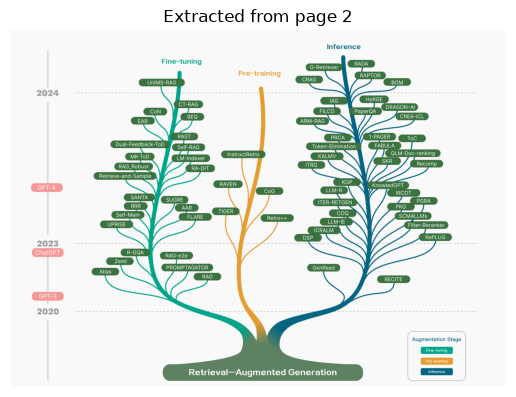

In [12]:
# Take a quick look at one extracted image
from PIL import Image
import matplotlib.pyplot as plt

if image_docs:
    im = Image.open(image_docs[0]["path"])
    plt.imshow(im)
    plt.axis("off")
    plt.title(f"Extracted from page {image_docs[0]['page']}")
    plt.show()
else:
    print("No images found in this PDF — try a report that includes a chart/diagram.")

## 5. Chunking (text only — tables & images are already the right size)

Same idea as basic RAG: long text needs to be split into small, retrievable pieces. Tables and images are naturally already 'one unit', so we don't chunk those — a whole table or a whole image becomes one retrievable item.

In [13]:
def chunk_text(text, chunk_size=600, overlap=100):
    """Simple sliding-window chunker on characters."""
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks

text_chunks = []  # [{"page": int, "text": str}]
for doc in text_docs:
    for chunk in chunk_text(doc["text"]):
        if chunk.strip():
            text_chunks.append({"page": doc["page"], "text": chunk})

print(f"Created {len(text_chunks)} text chunks from {len(text_docs)} pages.")

Created 229 text chunks from 21 pages.


## 6. Turn images into text (captioning with the local VLM)

This is the multimodal-specific step: we ask the VLM to describe each extracted image/chart in a sentence or two, so it can be embedded and searched **the same way as text**. The original image file path is kept in the metadata so we can show the VLM the *real* image later, at answer time.

In [16]:
def caption_image(path, page):
    b64 = image_to_base64(path)

    prompt = (
        f"This image is from page {page} of a business report. "
        "Describe what it shows in 1-2 factual sentences "
        "(e.g. chart type, what data/trend it shows, or diagram content)."
    )

    resp = requests.post(
        "http://localhost:11434/api/chat",
        json={
            "model": MODEL_NAME,
            "messages": [
                {
                    "role": "user",
                    "content": prompt,
                    "images": [b64]
                }
            ],
            "stream": False,
        }
    )

    print("Status:", resp.status_code)
    print("Response:", resp.text[:2000])

    resp.raise_for_status()

    data = resp.json()

    return data["message"]["content"].strip()

In [17]:
print(MODEL_NAME)

qwen2.5vl:3b


In [23]:
import base64
import requests

MODEL_NAME = "qwen2.5vl:3b"

def image_to_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def caption_image(path, page):

    b64 = image_to_base64(path)

    prompt = (
        f"This image is from page {page} of a business report. "
        "Describe what it shows in 1-2 factual sentences. "
        "Mention the chart type, important values, trends, "
        "or diagram content if visible."
    )

    payload = {
        "model": MODEL_NAME,

        "messages": [
            {
                "role": "user",
                "content": prompt,
                "images": [b64]
            }
        ],

        "stream": False,

        # Increase context size
        "options": {
            "num_ctx": 8192
        }
    }

    try:

        resp = requests.post(
            "http://localhost:11434/api/chat",
            json=payload,
            timeout=600
        )

        print("Status code:", resp.status_code)

        if resp.status_code != 200:
            print("Ollama error:")
            print(resp.text)
            resp.raise_for_status()

        data = resp.json()

        return data["message"]["content"].strip()

    except Exception as e:

        print("Error:", e)
        return None

In [24]:
caption = caption_image(
    image_docs[0]["path"],
    image_docs[0]["page"]
)

print("Caption:", caption)

Status code: 200
Caption: The image is a tree diagram illustrating the evolution of retrieval augmented generation (RAG) models from 2020 to 2024. It shows the progression from fine-tuning to pre-training and inference stages, with key models like G-Retriever, RAPTOR, and HyKGE emerging as prominent pre-training models. The timeline indicates the release of GPT-4 in 2024, GPT-3 in 2023, and GPT-3 in 2020, highlighting the development and adoption of these models over time.


In [ ]:
image_captions = []

for doc in image_docs:

    caption = caption_image(
        doc["path"],
        doc["page"]
    )

    image_captions.append({
        "page": doc["page"],
        "path": doc["path"],
        "caption": caption
    })

    print(f"[page {doc['page']}] {caption}")

In [ ]:
# import base64

# def image_to_base64(path):
#     with open(path, "rb") as f:
#         return base64.b64encode(f.read()).decode("utf-8")

# def caption_image(path, page):
#     """Ask the local VLM to describe an image/chart in 1-2 sentences."""
#     b64 = image_to_base64(path)
#     prompt = (
#         f"This image is from page {page} of a business report. "
#         "Describe what it shows in 1-2 factual sentences "
#         "(e.g. chart type, what data/trend it shows, or diagram content)."
#     )
#     resp = requests.post("http://localhost:11434/api/chat", json={
#         "model": MODEL_NAME,
#         "messages": [{"role": "user", "content": prompt, "images": [b64]}],
#         "stream": False,
#     })
#     return resp.json()["message"]["content"].strip()

# image_captions = []  # [{"page": int, "path": str, "caption": str}]
# for doc in image_docs:
#     caption = caption_image(doc["path"], doc["page"])
#     image_captions.append({"page": doc["page"], "path": doc["path"], "caption": caption})
#     print(f"[page {doc['page']}] {caption}")

KeyError: 'message'

In [26]:
import base64
import requests
import time


# ---------------------------------------------------------
# 1. Convert image to Base64
# ---------------------------------------------------------
def image_to_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


# ---------------------------------------------------------
# 2. Generate caption using Qwen2.5-VL
# ---------------------------------------------------------
def caption_image(path, page):

    b64 = image_to_base64(path)

    prompt = (
        f"This image is from page {page} of a business report. "
        "Describe what it shows in 1-2 factual sentences. "
        "Identify whether it is a chart, graph, table, or diagram. "
        "Mention important visible trends, labels, values, or relationships. "
        "Do not guess information that is not clearly visible."
    )

    payload = {
        "model": MODEL_NAME,

        "messages": [
            {
                "role": "user",
                "content": prompt,
                "images": [b64]
            }
        ],

        "stream": False,

        # Increase context size
        "options": {
            "num_ctx": 8192
        }
    }

    try:

        print(f"Processing page {page}...")

        response = requests.post(
            "http://localhost:11434/api/chat",
            json=payload,
            timeout=600
        )

        # Check HTTP error
        response.raise_for_status()

        result = response.json()

        # Safely get caption
        caption = result.get("message", {}).get("content", "").strip()

        if not caption:
            print(f"No caption returned for page {page}")
            print(result)
            return None

        return caption

    except requests.exceptions.Timeout:

        print(f"Timeout while processing page {page}")
        return None

    except requests.exceptions.ConnectionError:

        print("Could not connect to Ollama.")
        print("Make sure Ollama is running.")
        return None

    except requests.exceptions.HTTPError:

        print(f"Ollama HTTP error on page {page}:")
        print(response.text)
        return None

    except Exception as e:

        print(f"Unexpected error on page {page}: {e}")
        return None


# ---------------------------------------------------------
# 3. Process all images
# ---------------------------------------------------------
image_captions = []

for doc in image_docs:

    caption = caption_image(
        doc["path"],
        doc["page"]
    )

    image_captions.append({
        "page": doc["page"],
        "path": doc["path"],
        "caption": caption
    })

    print(f"[page {doc['page']}] {caption}")
    print("-" * 80)

    # Small delay between requests
    time.sleep(1)

Processing page 2...
[page 2] The image is a diagram that shows the evolution of retrieval augmented generation (RAG) models from 2020 to 2024. It categorizes these models into three stages: Fine-tuning, Pre-training, and Inference. The diagram uses different colors to represent these stages, with Fine-tuning in green, Pre-training in orange, and Inference in blue. The labels for each model are listed under the respective stages, indicating the progression and development of these models over time.
--------------------------------------------------------------------------------
Processing page 3...
[page 3] The image is a diagram that illustrates the process of a query being processed through an indexing, retrieval, and generation system. The diagram shows how a user's query is indexed, retrieved from relevant documents, and then combined with context and prompts to generate an answer. The diagram highlights the steps involved in this process, including the indexing of documents, the r

## 7. Embeddings — one shared vector space for everything

We now embed **text chunks**, **table markdown**, and **image captions** using the *same* Sentence-Transformers model. This is exactly the embedding step from basic RAG — nothing new here, which is the point: multimodal content just needs to be turned into text-like representations *before* this step.

In [27]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer("all-MiniLM-L6-v2")

# metadata[i] describes what vectors[i] represents
metadata = []
texts_to_embed = []

for c in text_chunks:
    metadata.append({"type": "text", "page": c["page"], "content": c["text"], "image_path": None})
    texts_to_embed.append(c["text"])

for t in table_docs:
    metadata.append({"type": "table", "page": t["page"], "content": t["markdown"], "image_path": None})
    texts_to_embed.append(t["markdown"])

for img in image_captions:
    metadata.append({"type": "image", "page": img["page"], "content": img["caption"], "image_path": img["path"]})
    texts_to_embed.append(img["caption"])

embeddings = embedder.encode(texts_to_embed, show_progress_bar=True, normalize_embeddings=True)
embeddings = np.array(embeddings).astype("float32")

print(f"Embedded {len(texts_to_embed)} items -> vectors of dimension {embeddings.shape[1]}")
print("Breakdown:", {t: sum(1 for m in metadata if m["type"] == t) for t in ["text", "table", "image"]})

c:\Users\Lova Kumar\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 8/8 [00:11<00:00,  1.46s/it]

Embedded 235 items -> vectors of dimension 384
Breakdown: {'text': 229, 'table': 0, 'image': 6}


## 8. Build the FAISS vector store

Identical to basic text RAG — FAISS doesn't know or care that some of these vectors originally came from an image. That's exactly why the captioning trick in Step 6 is useful.

In [28]:
import faiss

dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # inner product on normalized vectors = cosine similarity
index.add(embeddings)

print(f"FAISS index built with {index.ntotal} vectors.")

FAISS index built with 235 vectors.


## 9. Retriever

Same retrieval function you already know from basic RAG. It returns whichever content type is most relevant — text, table, or image — the retriever doesn't need to know the difference.

In [29]:
def retrieve(query, k=3):
    query_vec = embedder.encode([query], normalize_embeddings=True).astype("float32")
    scores, indices = index.search(query_vec, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue
        item = dict(metadata[idx])
        item["score"] = float(score)
        results.append(item)
    return results

# Quick test
for r in retrieve("revenue", k=3):
    print(f"[{r['type']}] page {r['page']} (score={r['score']:.2f}) -> {r['content'][:80]}...")

[text] page 21 (score=0.21) -> 3, pp.
2450–2462....
[text] page 11 (score=0.17) -> lformer, for instance, di-
vides its retrieval process into distinct steps where...
[text] page 15 (score=0.17) -> 
Generation Quality
Context Relevance
Faithfulness
Answer Relevance
Accuracy
Acc...


## 10. Multimodal generation — assembling context and calling the VLM

This is where multimodal RAG diverges from text RAG at the *generation* stage:

- Retrieved **text** and **table** items are added as plain text context in the prompt (same as basic RAG).
- Retrieved **image** items are sent to the VLM as an **actual image**, not just their caption — so the model can really look at the chart/diagram before answering.

**Expected output:** a natural-language answer, plus a printout of which chunks (and their type) were used — useful for explaining *why* the model answered the way it did.

In [33]:
import base64
import requests

from IPython.display import display, Image as IPImage


# =========================================================
# 1. Convert image to Base64
# =========================================================

def image_to_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


# =========================================================
# 2. Display an image
# =========================================================

def display_image(path, page=None):

    try:

        if page is not None:
            print(f"\nImage from page {page}:")
        else:
            print("\nImage:")

        print("Path:", path)

        display(IPImage(filename=path))

    except Exception as e:

        print(f"Could not display image: {e}")


# =========================================================
# 3. Generate answer using retrieved text + images
# =========================================================

def generate_answer(query, k=3, verbose=True):

    # -----------------------------------------------------
    # Retrieve relevant documents
    # -----------------------------------------------------

    results = retrieve(query, k=k)

    text_context = []
    image_paths = []

    # -----------------------------------------------------
    # Separate text/table/image results
    # -----------------------------------------------------

    for r in results:

        if r["type"] in ("text", "table"):

            text_context.append(
                f"[Page {r['page']}, {r['type']}]\n"
                f"{r['content']}"
            )

        elif r["type"] == "image":

            # Add image caption to text context
            text_context.append(
                f"[Page {r['page']}, image]\n"
                f"Caption: {r['content']}"
            )

            # Store image path
            image_paths.append(r["image_path"])

    # -----------------------------------------------------
    # PRINT RETRIEVED SOURCES
    # -----------------------------------------------------

    if verbose:

        print("=" * 70)
        print("RETRIEVED SOURCES")
        print("=" * 70)

        for i, r in enumerate(results, start=1):

            print(
                f"{i}. Type: {r['type']} | "
                f"Page: {r['page']} | "
                f"Score: {r['score']:.4f}"
            )

    # -----------------------------------------------------
    # DISPLAY RETRIEVED IMAGES
    # -----------------------------------------------------

    if verbose:

        print("\n")
        print("=" * 70)
        print("RETRIEVED IMAGES")
        print("=" * 70)

        if image_paths:

            for r in results:

                if r["type"] == "image":

                    display_image(
                        r["image_path"],
                        r["page"]
                    )

        else:

            print("No images were retrieved.")

    # -----------------------------------------------------
    # CREATE TEXT CONTEXT
    # -----------------------------------------------------

    context_block = "\n\n".join(text_context)

    # -----------------------------------------------------
    # CREATE PROMPT
    # -----------------------------------------------------

    prompt = (
        "You are answering a question about a business report.\n\n"

        "Use ONLY the provided text context and the attached images.\n"

        "If the answer is not available in the context or images, "
        "say that the information is not available.\n\n"

        "Do not invent values, dates, names, or relationships.\n\n"

        f"Context:\n{context_block}\n\n"

        f"Question: {query}"
    )

    # -----------------------------------------------------
    # CREATE MESSAGE
    # -----------------------------------------------------

    message = {
        "role": "user",
        "content": prompt
    }

    # -----------------------------------------------------
    # ATTACH RETRIEVED IMAGES
    # -----------------------------------------------------

    if image_paths:

        message["images"] = [
            image_to_base64(path)
            for path in image_paths
        ]

    # -----------------------------------------------------
    # SEND REQUEST TO OLLAMA
    # -----------------------------------------------------

    print("\n")
    print("=" * 70)
    print("ASKING QWEN2.5-VL")
    print("=" * 70)

    try:

        response = requests.post(
            "http://localhost:11434/api/chat",

            json={
                "model": MODEL_NAME,

                "messages": [message],

                "stream": False,

                "options": {
                    # Prevent the previous 4096-token error
                    "num_ctx": 8192
                }
            },

            # Qwen2.5-VL can take some time
            timeout=600
        )

        # Check HTTP errors
        response.raise_for_status()

        data = response.json()

        # Get answer
        answer = data["message"]["content"].strip()

    except requests.exceptions.Timeout:

        print("ERROR: Ollama request timed out.")
        return None

    except requests.exceptions.ConnectionError:

        print(
            "ERROR: Could not connect to Ollama.\n"
            "Make sure Ollama is running."
        )

        return None

    except requests.exceptions.HTTPError:

        print("OLLAMA ERROR:")
        print(response.text)

        return None

    except Exception as e:

        print("ERROR:", e)

        return None

    # -----------------------------------------------------
    # PRINT ANSWER
    # -----------------------------------------------------

    if verbose:

        print("\n")
        print("=" * 70)
        print("ANSWER")
        print("=" * 70)

        print(answer)

    return answer

In [ ]:
# def generate_answer(query, k=3, verbose=True):
#     results = retrieve(query, k=k)

#     text_context = []
#     image_paths = []
#     for r in results:
#         if r["type"] in ("text", "table"):
#             text_context.append(f"[Page {r['page']}, {r['type']}]\n{r['content']}")
#         elif r["type"] == "image":
#             text_context.append(f"[Page {r['page']}, image] Caption: {r['content']}")
#             image_paths.append(r["image_path"])

#     context_block = "\n\n".join(text_context)
#     prompt = (
#         "Answer the question using ONLY the context below. "
#         "If the answer isn't in the context, say so.\n\n"
#         f"Context:\n{context_block}\n\nQuestion: {query}"
#     )

#     message = {"role": "user", "content": prompt}
#     if image_paths:
#         message["images"] = [image_to_base64(p) for p in image_paths]

#     resp = requests.post("http://localhost:11434/api/chat", json={
#         "model": MODEL_NAME,
#         "messages": [message],
#         "stream": False,
#     })
#     answer = resp.json()["message"]["content"]

#     if verbose:
#         print("Retrieved sources:")
#         for r in results:
#             print(f"  - [{r['type']}] page {r['page']} (score={r['score']:.2f})")
#         print("\nAnswer:\n", answer)

#     return answer

## 11. Classroom demo questions

Run each cell and discuss which content type the retriever pulled from.

In [34]:
generate_answer("What does the document say about the company's revenue?")

RETRIEVED SOURCES
1. Type: text | Page: 21 | Score: 0.2690
2. Type: text | Page: 8 | Score: 0.1628
3. Type: text | Page: 17 | Score: 0.1624


RETRIEVED IMAGES
No images were retrieved.


ASKING QWEN2.5-VL


ANSWER
The document does not provide specific information about the company's revenue.


"The document does not provide specific information about the company's revenue."

In [35]:
generate_answer("how rag working?")

RETRIEVED SOURCES
1. Type: text | Page: 1 | Score: 0.6945
2. Type: text | Page: 1 | Score: 0.6616
3. Type: text | Page: 2 | Score: 0.6248


RETRIEVED IMAGES
No images were retrieved.


ASKING QWEN2.5-VL


ANSWER
The RAG process involves three main stages: "Retrieval," "Generation," and "Augmentation." These stages work together to create a cohesive and effective RAG framework.


'The RAG process involves three main stages: "Retrieval," "Generation," and "Augmentation." These stages work together to create a cohesive and effective RAG framework.'

RETRIEVED SOURCES
1. Type: image | Page: 3 | Score: 0.5120
2. Type: image | Page: 7 | Score: 0.4872
3. Type: image | Page: 2 | Score: 0.3779


RETRIEVED IMAGES

Image from page 3:
Path: data/extracted_images/page3_img2.png


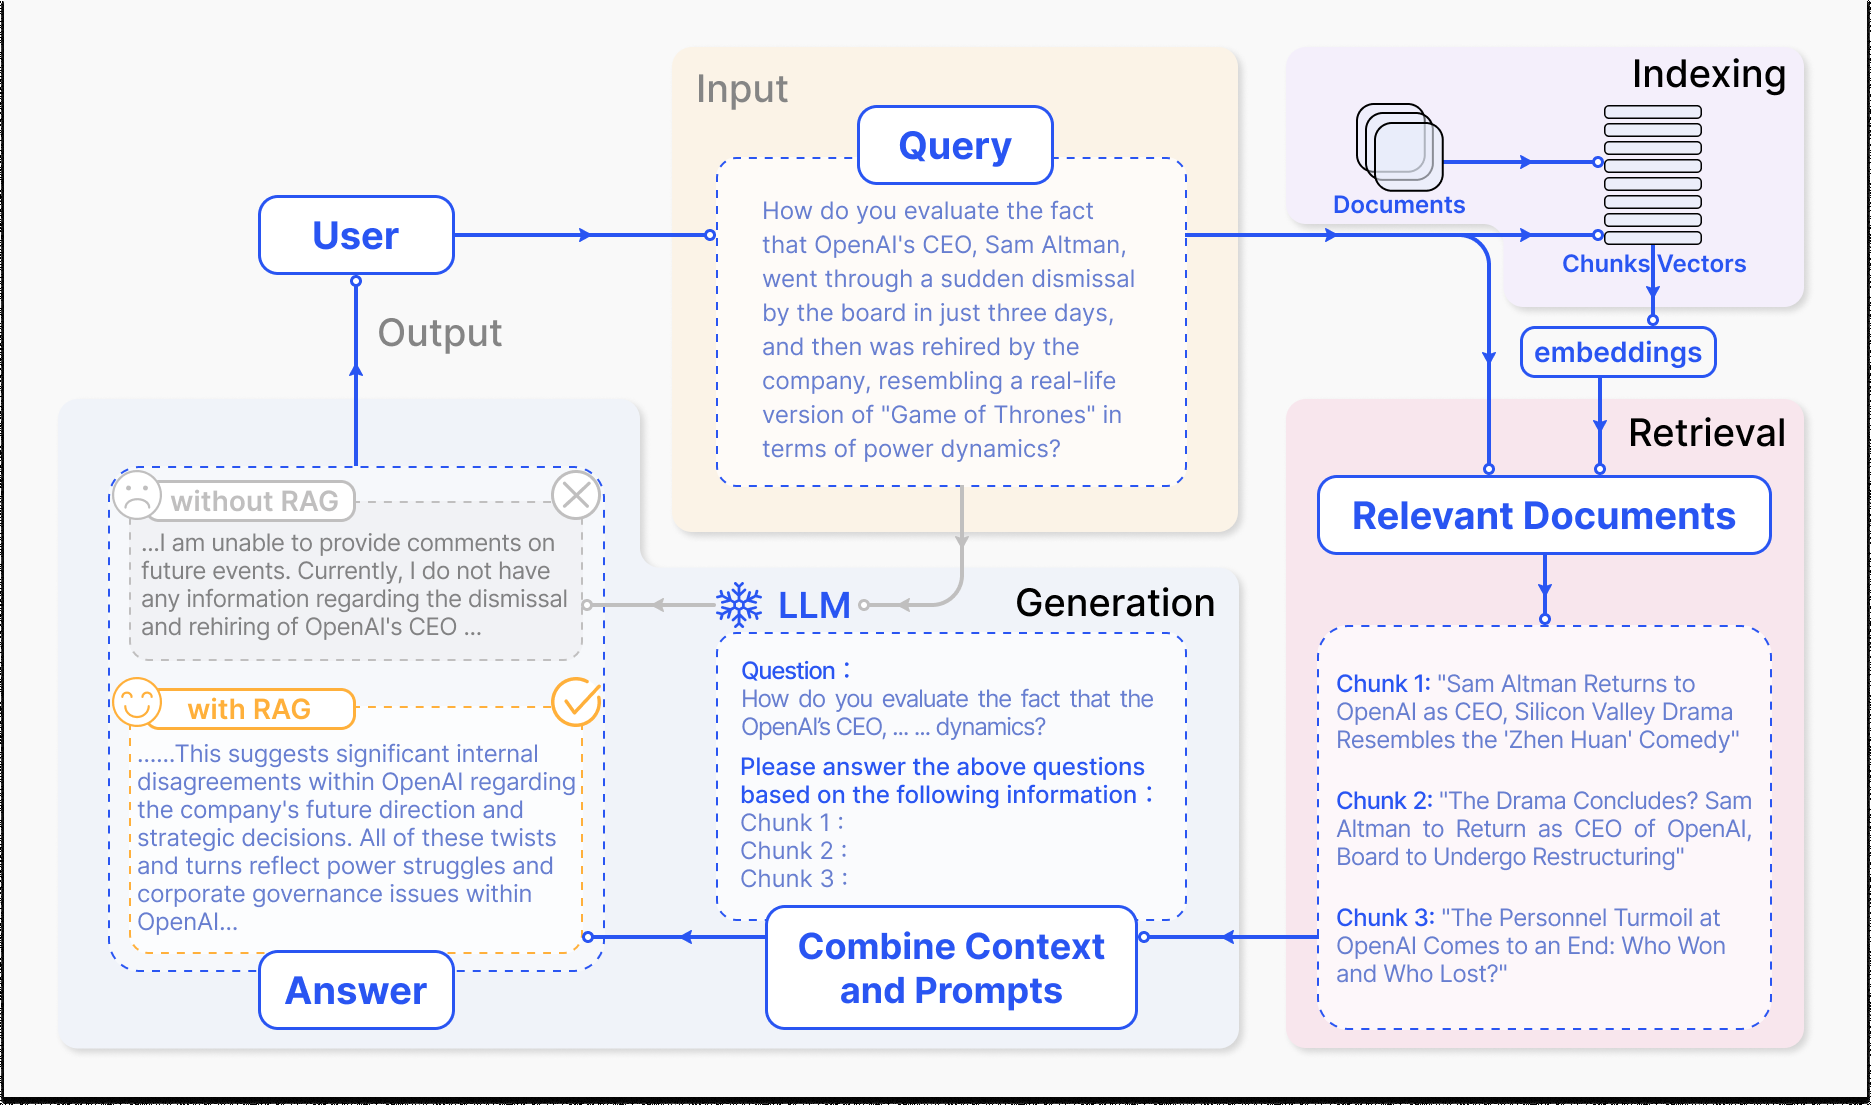


Image from page 7:
Path: data/extracted_images/page7_img4.png


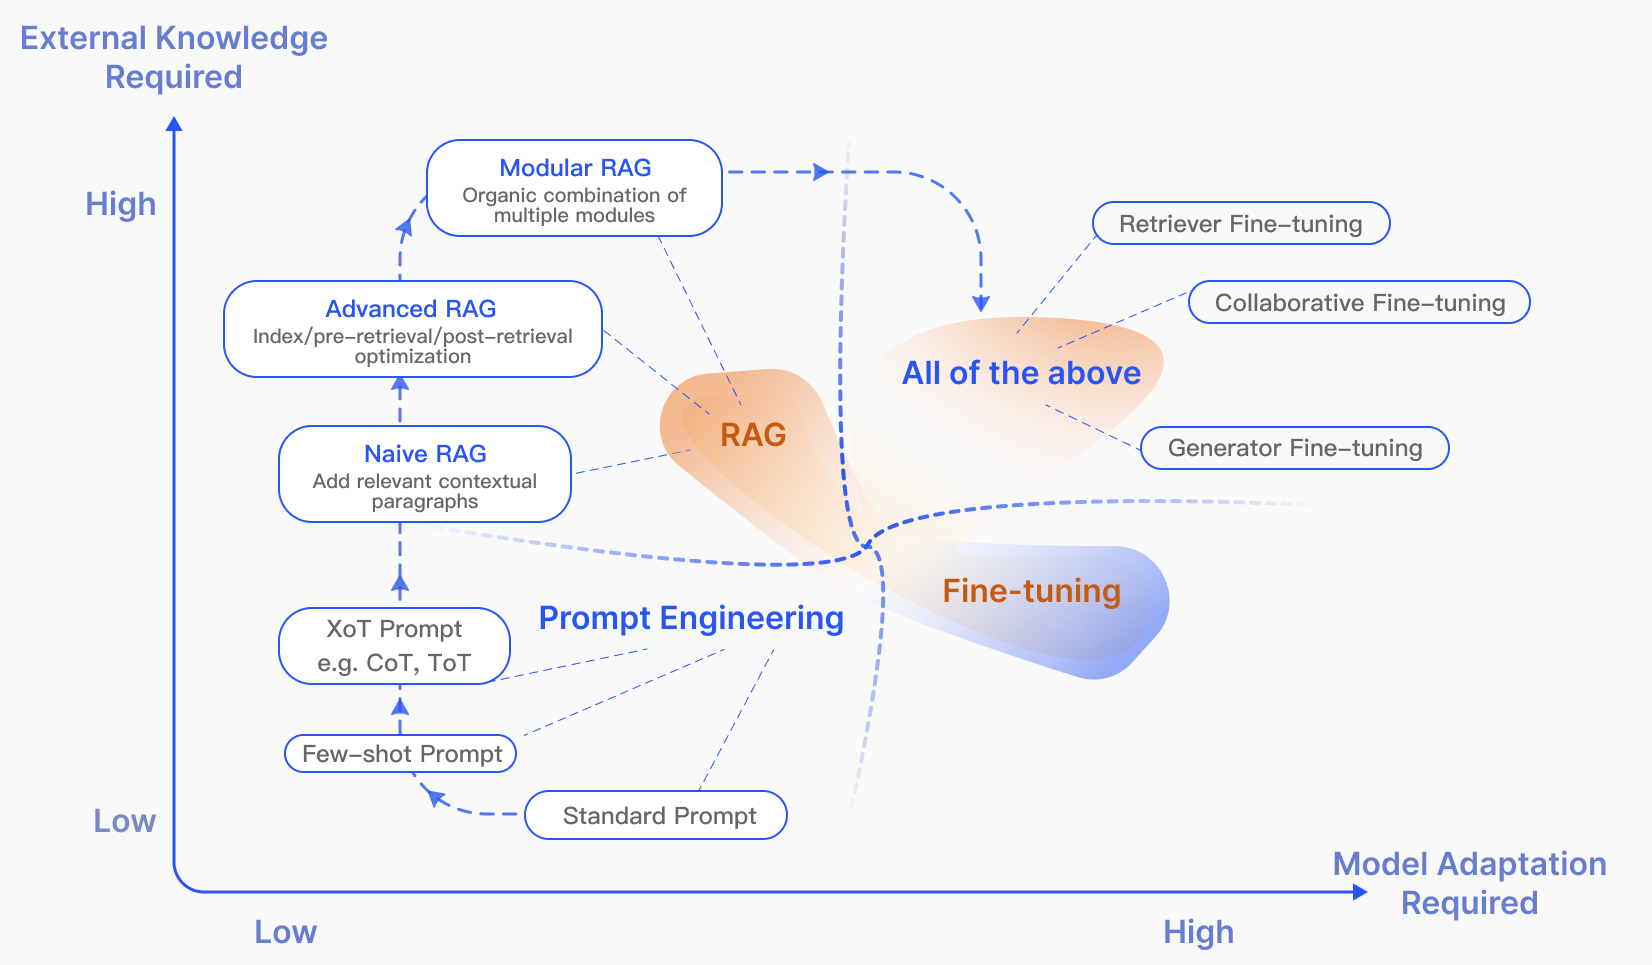


Image from page 2:
Path: data/extracted_images/page2_img1.png


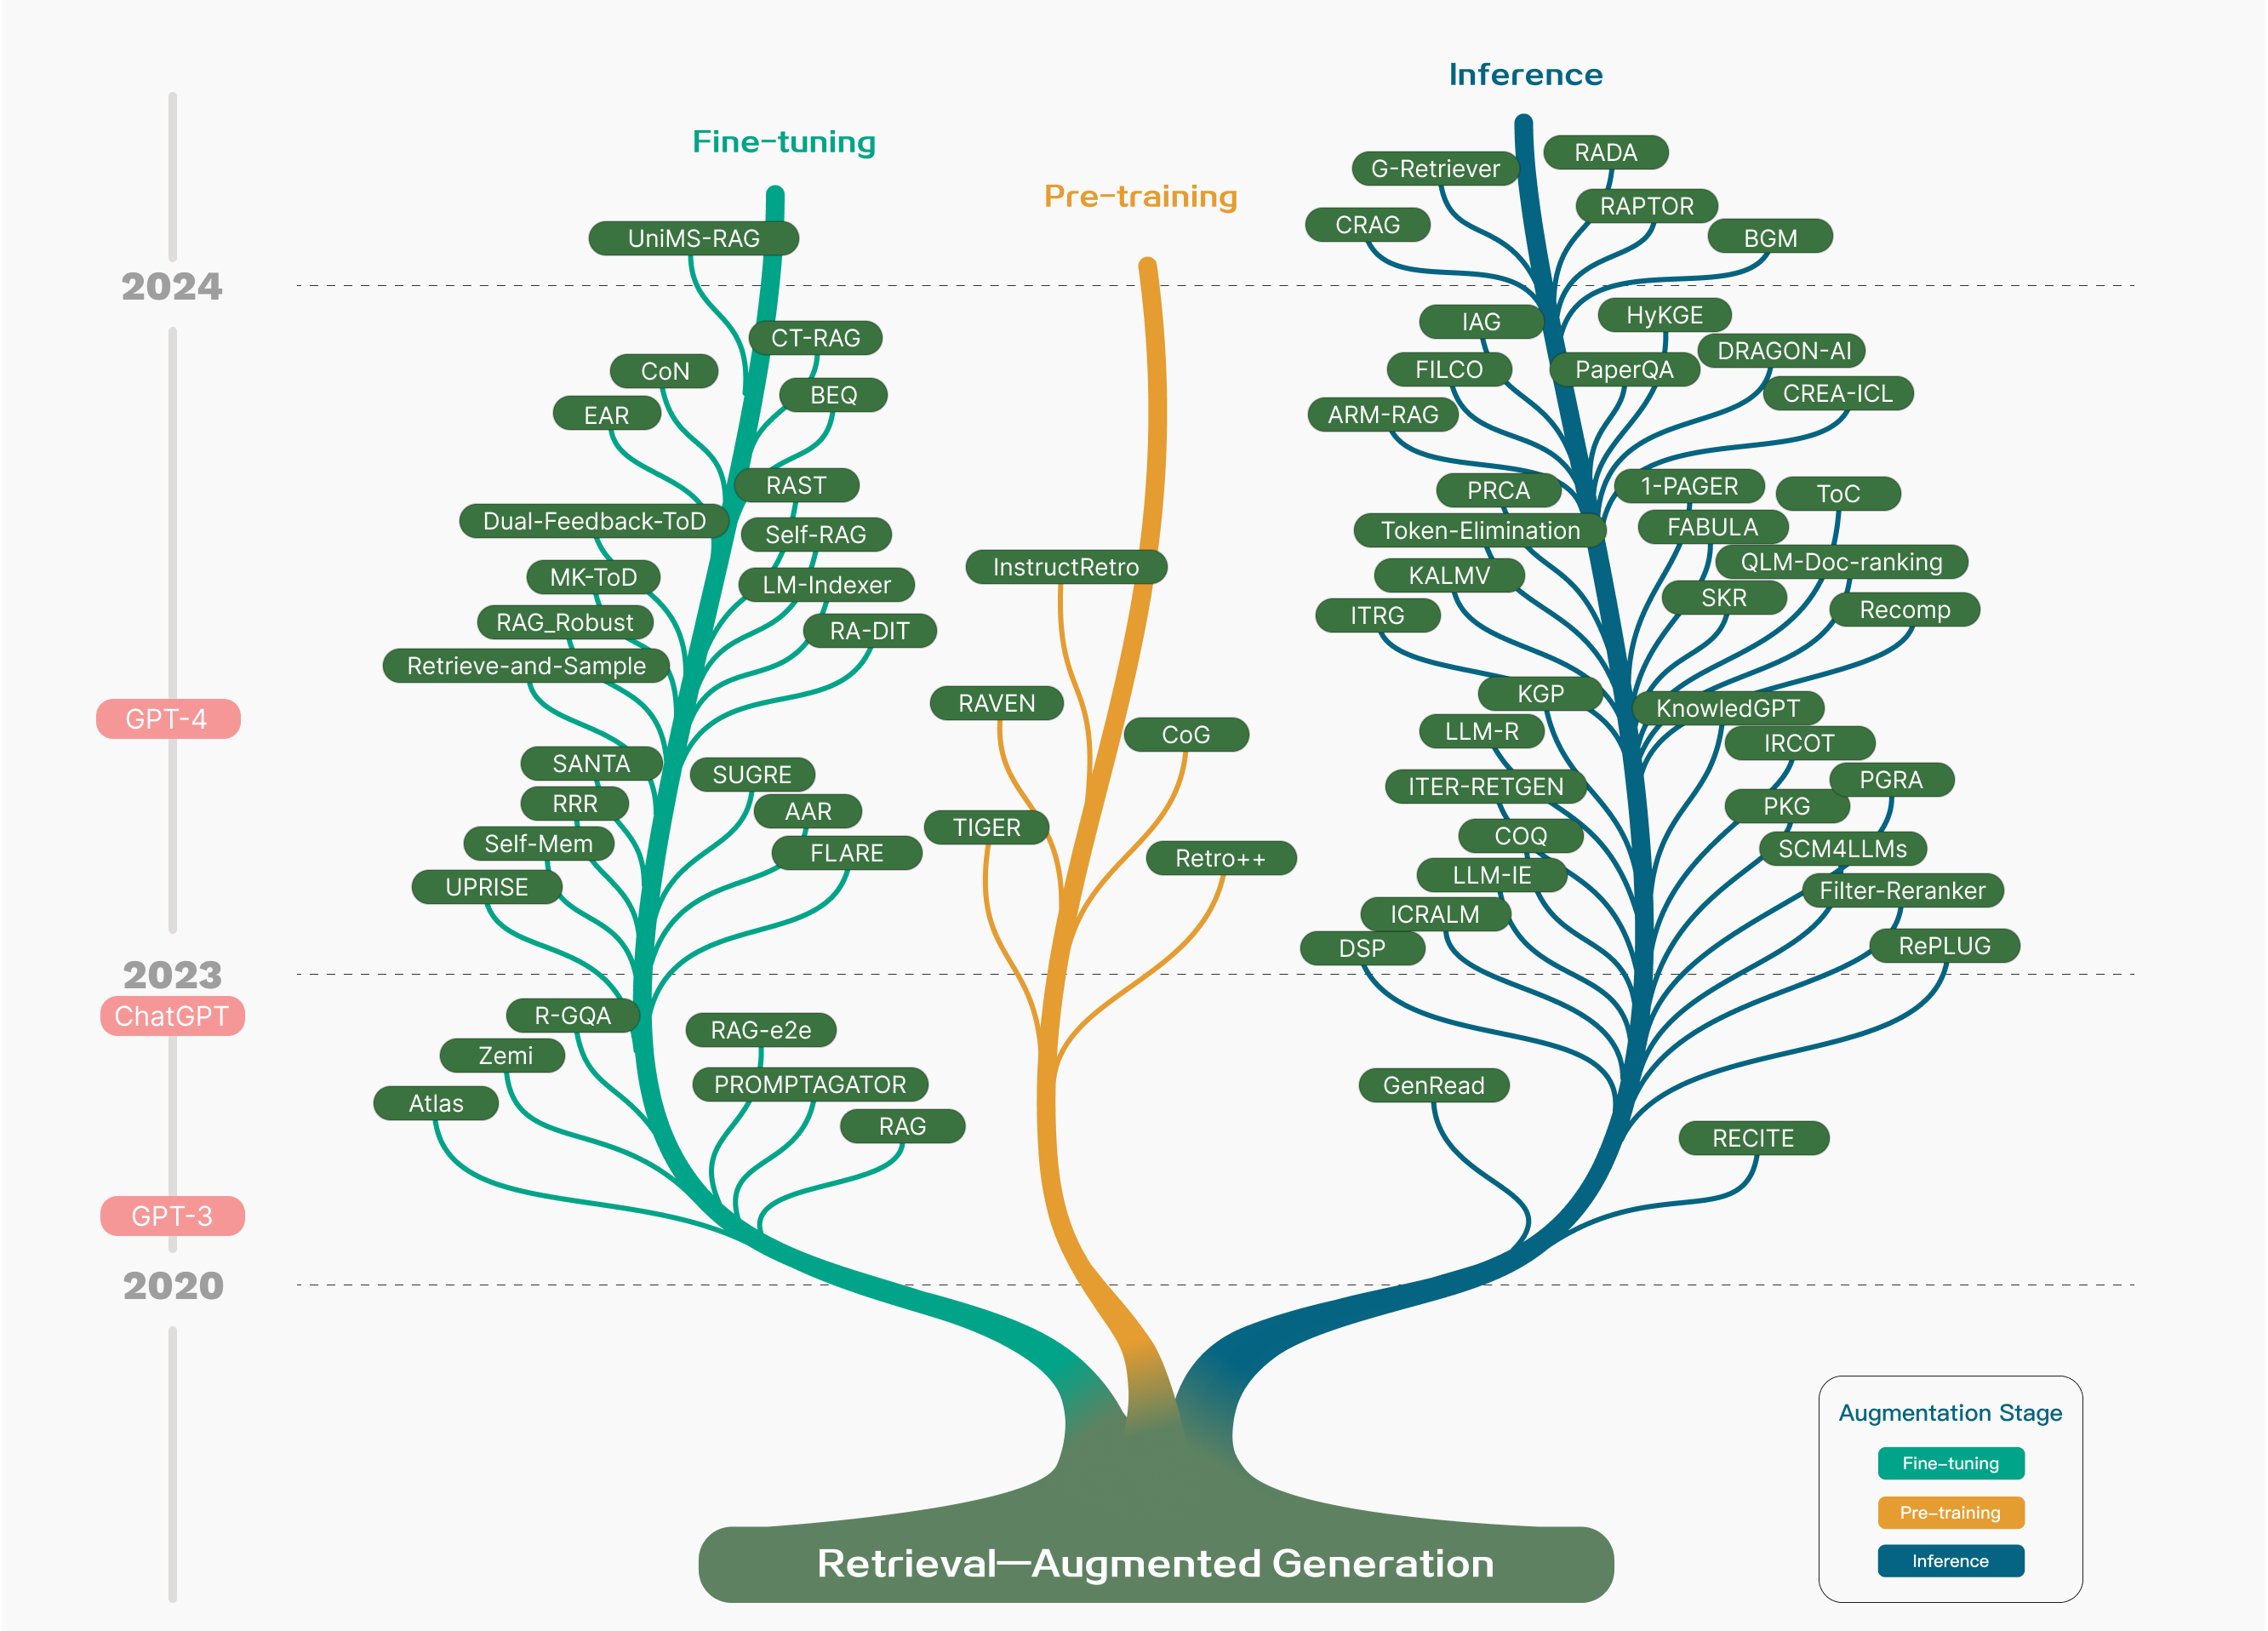



ASKING QWEN2.5-VL
OLLAMA ERROR:
{"error":"{\"error\":{\"code\":400,\"message\":\"request (9071 tokens) exceeds the available context size (8192 tokens), try increasing it\",\"type\":\"exceed_context_size_error\",\"n_prompt_tokens\":9071,\"n_ctx\":8192}}"}


In [36]:
# Adjust the page number to match a chart/image in your PDF
generate_answer("Explain the chart or image on this page.")

RETRIEVED SOURCES
1. Type: image | Page: 11 | Score: 0.6088
2. Type: text | Page: 10 | Score: 0.5080
3. Type: text | Page: 11 | Score: 0.4059


RETRIEVED IMAGES

Image from page 11:
Path: data/extracted_images/page11_img5.png


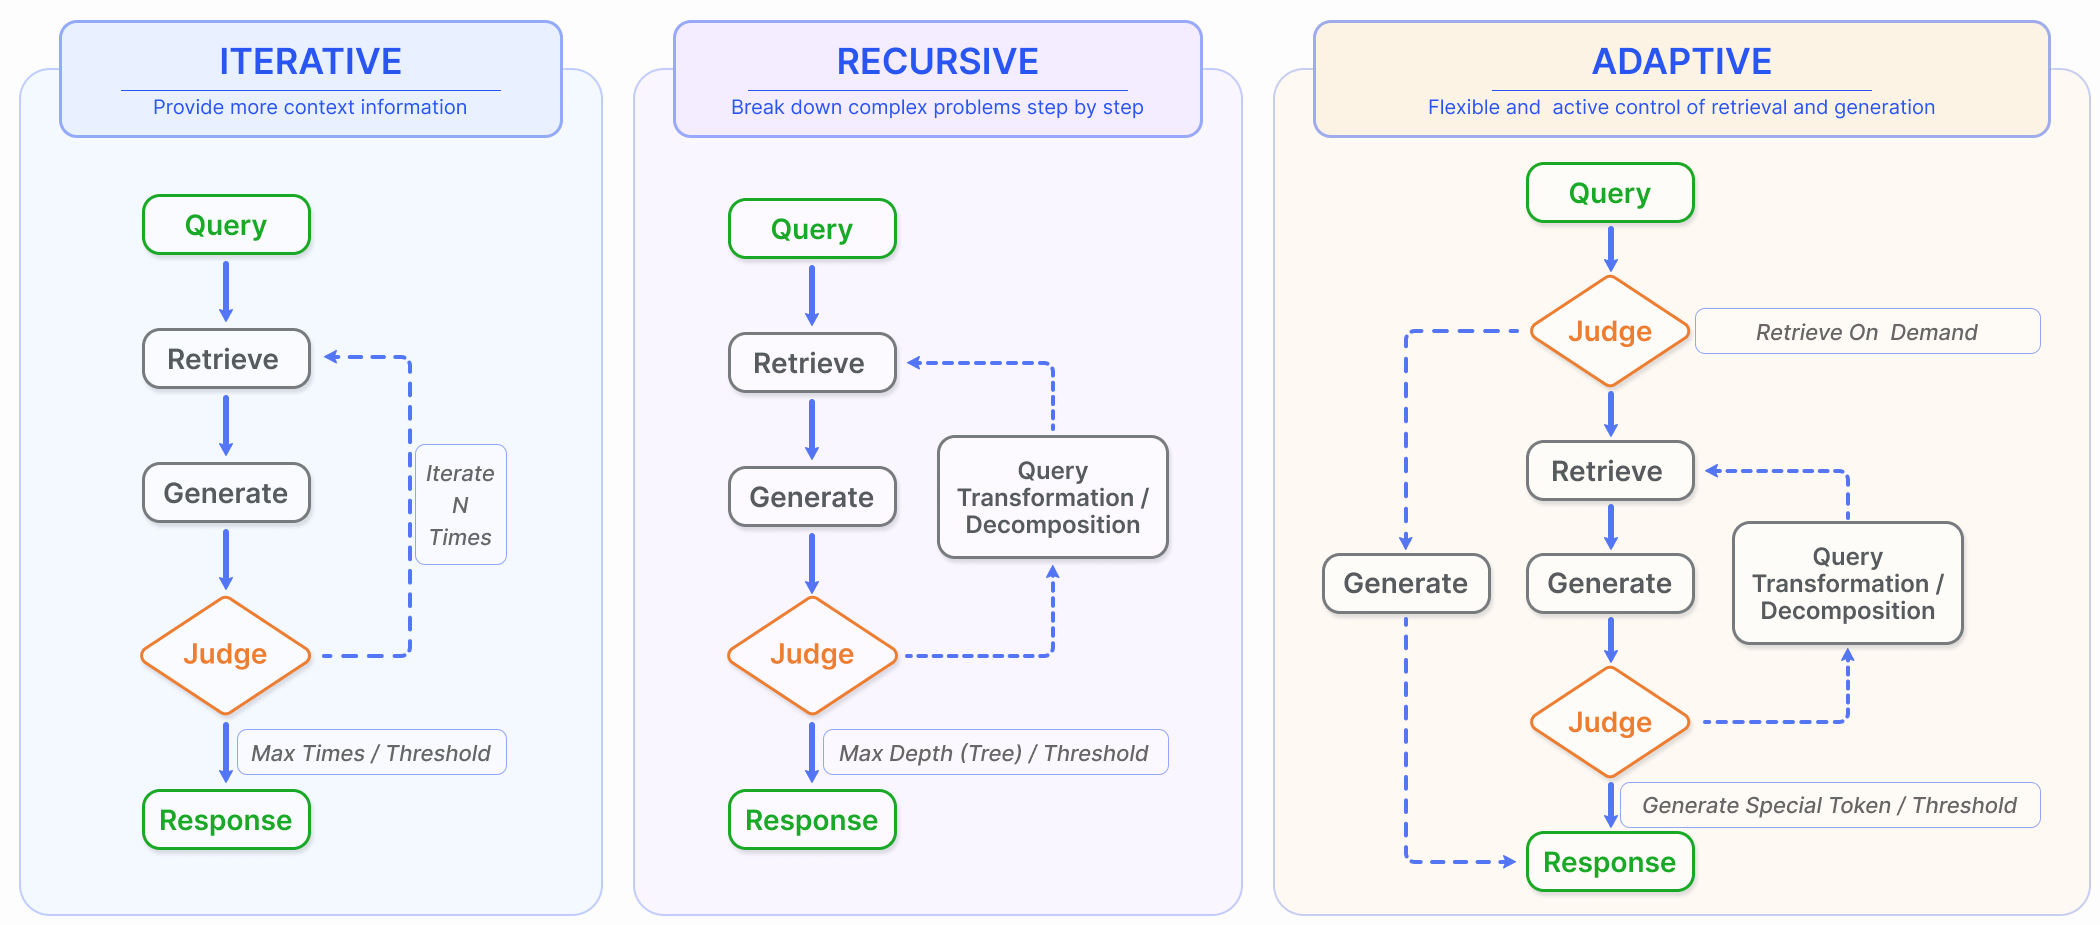



ASKING QWEN2.5-VL


ANSWER
Iterative retrieval involves alternating between retrieval and generation, allowing for richer and more targeted context from the knowledge base at each step.


'Iterative retrieval involves alternating between retrieval and generation, allowing for richer and more targeted context from the knowledge base at each step.'

In [37]:
generate_answer("What is mean by iterative?")

In [39]:
generate_answer("what are the different types of RAG methods?")

RETRIEVED SOURCES
1. Type: text | Page: 1 | Score: 0.6178
2. Type: text | Page: 1 | Score: 0.6065
3. Type: text | Page: 4 | Score: 0.5976


RETRIEVED IMAGES
No images were retrieved.


ASKING QWEN2.5-VL


ANSWER
The different types of RAG methods mentioned in the context are:

1. Naive RAG
2. Advanced RAG
3. Modular RAG


'The different types of RAG methods mentioned in the context are:\n\n1. Naive RAG\n2. Advanced RAG\n3. Modular RAG'

## 12. Recap: what actually changed vs. basic text RAG?

| Step | Basic RAG | Multimodal RAG (today) |
|---|---|---|
| Extraction | Text only | Text + tables + images, each with its own extractor |
| Representation | Text chunks | Text chunks + table-as-markdown + image captions |
| Embedding | Sentence-Transformers | **Same** — one shared model, one shared index |
| Vector store | FAISS | **Same** |
| Retrieval | Top-k similarity search | **Same** |
| Generation | Text-only LLM call | VLM call — real image attached when an image chunk is retrieved |

The retrieval *engine* barely changed. Almost all the new work is in **extraction** (getting each content type out cleanly) and **generation** (giving the model the real image, not just a caption, when it matters).

## 13. Optional improvements for advanced students

- **True joint embeddings**: replace the caption-then-embed trick with a CLIP-style model (e.g. `open_clip`) so images are embedded directly, without a captioning round-trip.
- **Better table understanding**: try `camelot-py` for tables with complex merged cells, or ask the VLM to answer questions directly from a *rendered image* of the table instead of markdown text.
- **Re-ranking**: add a cross-encoder re-ranker on top of the FAISS top-k results before sending context to the LLM.
- **Routing**: instead of one retriever for everything, build a lightweight classifier that decides if a question is 'about a table' vs 'about an image' vs 'general text', and biases retrieval accordingly.
- **Video extension** (not built today, but a natural next step): sample frames from a video with OpenCV every N seconds, caption each frame the same way we captioned images here, embed captions, and reuse this exact retrieval + generation pipeline. Optionally transcribe audio with a local Whisper model and treat the transcript like another text document.
- **Bigger models**: swap `MODEL_NAME` to `qwen2.5vl:7b` or `qwen2.5vl:32b` (if VRAM allows) for noticeably better chart-reading accuracy.

## 14. Troubleshooting

| Problem | Likely cause | Fix |
|---|---|---|
| `ollama: command not found` | Install cell didn't finish | Re-run the install cell, then restart runtime if needed |
| Ollama server check keeps failing | Server needs a few more seconds, or a previous process is stuck | Re-run the `subprocess.Popen` cell; if stuck, `Runtime → Restart runtime` and start over |
| `ollama pull` is slow | Colab's network speed varies | Use `qwen2.5vl:3b` (smaller) instead of 7b for a live class |
| No images extracted from PDF | Charts might be vector-drawn, not embedded raster images | Use a PDF where charts are inserted as images/screenshots, or render the page itself as an image with `page.get_pixmap()` and treat that as the 'image' for that page |
| No tables extracted | `pdfplumber` needs visible grid lines/whitespace structure | Try a PDF with a clearer bordered table, or fall back to manually typing the table text for the demo |
| CUDA / GPU errors | Runtime not set to GPU | `Runtime → Change runtime type → T4 GPU` |
| Answers ignore the image | The question didn't match the image's caption closely enough to be retrieved | Increase `k` in `generate_answer`, or ask a more specific question mentioning 'chart' or 'diagram' |

## 15. 30–40 Minute Teaching Flow

| Time | Segment |
|---|---|
| 0–5 min | Recap basic RAG diagram → introduce multimodal RAG diagram (cells 1-2) |
| 5–10 min | Setup: GPU check, installs, start Ollama, pull model (cells 3-8) — can be pre-run before class to save time |
| 10–15 min | Content extraction: run text/table/image extraction, show the raw outputs (cells 9-14) |
| 15–18 min | Chunking + image captioning — emphasize this is the 'bridge' step (cells 15-17) |
| 18–23 min | Embeddings + FAISS index — point out this is identical to what they already know (cells 18-21) |
| 23–28 min | Retrieval + multimodal generation function walkthrough (cells 22-25) |
| 28–35 min | Run all 5 demo questions live, discuss retrieved sources for each (cells 26) |
| 35–40 min | Recap table (cell 27) + optional improvements + Q&A |

**Tip:** run Steps 1–2 (installs, Ollama pull) *before* class starts so students aren't waiting on downloads during the live session.